# Problem 3: Galaxy classification
*30 points*

In this problem, we adapt the image classification notebooks from class to perform image classification on the GalaxyMNIST dataset. We will create and train a few different neural networks and quantify their performance. 

The GalaxyMNIST dataset is hosted at https://github.com/mwalmsley/galaxy-datasets. It contains 10,000 galaxy images, assigned to four categories:

```
labels = {
    0: "smooth-round", 
    1: "smooth-cigar", 
    2: "edge-on-disk", 
    3: "unbarred-spiral"
}
```

The dataset is a "debugging" subset of a much larger collection of galaxy images (with many more labels), but is sufficient for our purposes. See [arXiv:2102.08414](https://arxiv.org/abs/2102.08414), as well as the README in the git repository, for more details on how the dataset was constructed. 

### WARNING

Training the neural network will take a fair amount of time: the input images are 224 x 224 pixels, versus 28 x 28 pixels for MNIST, so training will take roughly 100x as long. On my M4 Pro CPU, the first step takes about 15 minutes to train. Therefore, you will have to start early and plan carefully. Some recommendations:

- Use `tqdm` to create a progress bar with time estimate during the training. If the time estimate is too large, you can stop the kernel and revise the parameters to achieve a reasonable training time.
- Each time you obtain a successful training, **save the results**! The Jax MNIST notebook shows how to export the trained weights at the end. See the notebook `restore.ipynb` for how to load the saved parameters.
- Given the computational limitations of running this on a laptop, you will not be graded on absolute accuracy, but rather on following the right training and evaluation methods. 

In [1]:
!pip install hist
!pip install tensorflow_datasets
!pip install importlib_resources
!pip install jax
!pip install flax
!pip install https://github.com/ubsuny/galaxy_datasets/archive/refs/tags/v0.1.zip

  Using cached https://github.com/ubsuny/galaxy_datasets/archive/refs/tags/v0.1.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import numpy as np
import requests
import gzip
import shutil
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import hist
import tensorflow as tf
import tensorflow_datasets as tfds
from tqdm import tqdm
from galaxy_datasets.galaxy_mnist_dataset_builder import GalaxyMNIST
from IPython.display import clear_output
import jax.numpy as jnp  # JAX NumPy
import optax
from flax import nnx
import jax

from functools import partial
from typing import Optional
import numpy as np
import jax.numpy as jnp
import seaborn as sns
import hist

2026-04-15 21:24:03.096070: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-15 21:24:03.343532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Dataset loader

For this problem, a `tensorflow_dataset` wrapper has been created to load the dataset in exactly the same way as the JAX MNIST tutorial. The wrapper is in a python package at https://github.com/ubsuny/galaxy_datasets. If you are using the Docker container, this python package has already been installed (run `docker pull ubsuny/compphys:latest` to pull the latest version). Otherwise, you can install it with pip:

`pip install git+https://github.com/ubsuny/galaxy_datasets@v0.1`

The first time you run this notebook, the dataset will be downloaded to `data_dir`. If you are using the Docker container, make sure that `data_dir` is somewhere persistent, otherwise it will get deleted every time you stop the container.

In [3]:
tfds.disable_progress_bar() # Verbose extraction step breaks the progress bar
tf.random.set_seed(0)  # Set the random seed for reproducibility.

train_steps = 2500
#750
eval_every = 50
batch_size = 16

train_ds: tf.data.Dataset
ds_info: tfds.core.DatasetInfo
train_ds, ds_info = tfds.load("GalaxyMNIST", split="train", with_info=True, data_dir="./data") #GalaxyMNIST(split="train")

# Image preprocessing
train_ds = train_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    #'image': tf.reduce_mean(tf.cast(sample['image'], tf.float32), axis=-1, keepdims=True) / 255,
    'label': sample['label'],
  }
)  # normalize train set

test_ds = tfds.load("GalaxyMNIST", split="test", data_dir="./data") #GalaxyMNIST(split="test")

test_ds = test_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    #'image': tf.reduce_mean(tf.cast(sample['image'], tf.float32), axis=-1, keepdims=True) / 255,
    'label': sample['label'],
  }
)  # Normalize the test set.

# Create a shuffled dataset by allocating a buffer size of 1024 to randomly draw elements from.
train_ds = train_ds.repeat().shuffle(1024)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
train_ds = train_ds.batch(batch_size, drop_remainder=True).take(train_steps).prefetch(8)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
test_ds = test_ds.batch(batch_size, drop_remainder=True).prefetch(8)

tfds.enable_progress_bar()
print("Done")


Done


2026-04-15 21:24:06.922762: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Cat 0 = smooth-round
Cat 1 = smooth-cigar
Cat 2 = edge-on-disk
Cat 3 = unbarred-spiral


2026-04-15 21:24:07.242937: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-04-15 21:24:07.276497: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


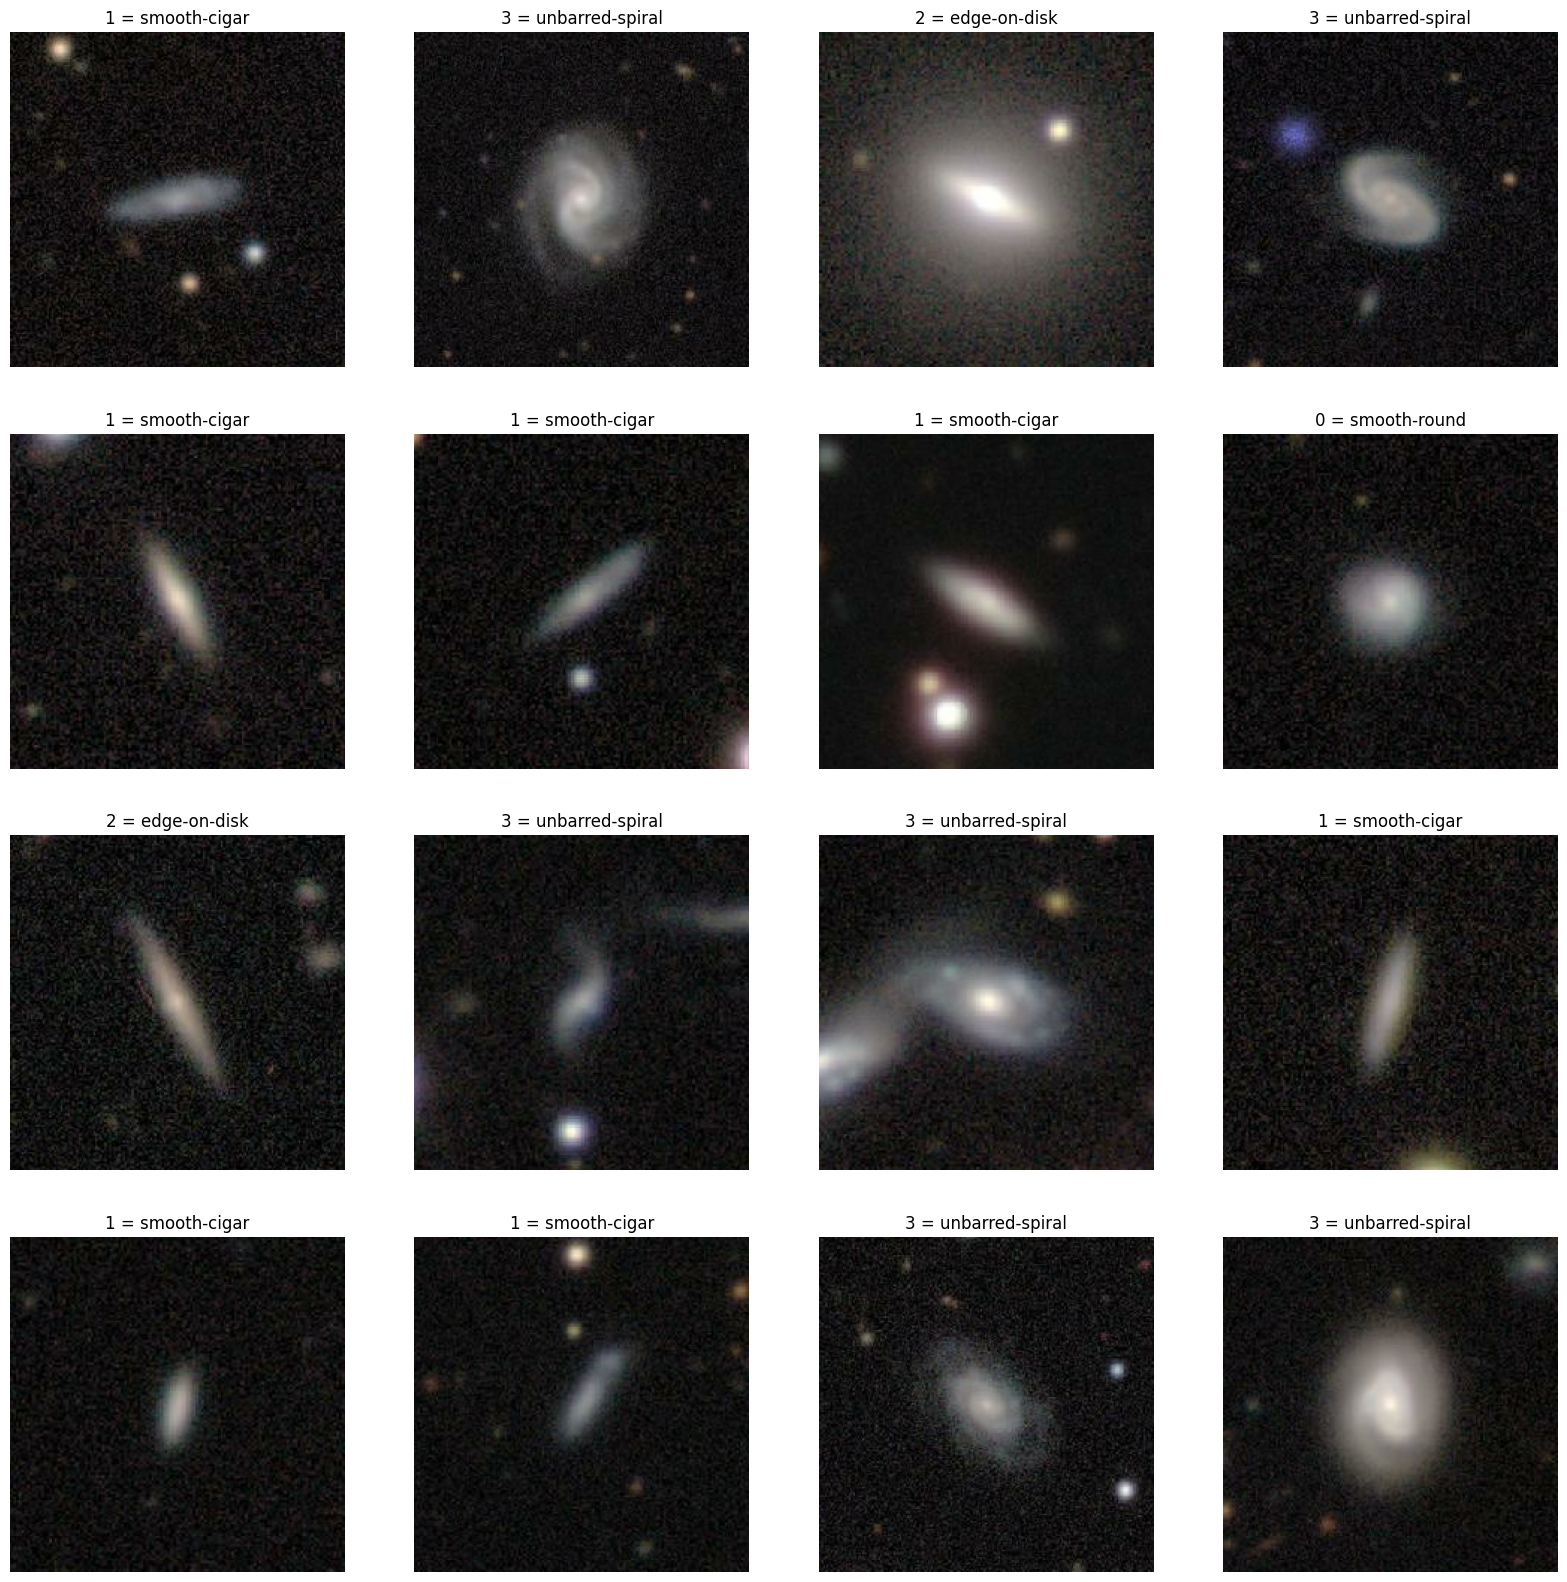

In [4]:
# Label info
ds_info
cat_map = ds_info.features["label"]
for i in range(4):
    print(f"Cat {i} = {cat_map.int2str(i)}")

# Inspect a few images
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
test_batch = test_ds.take(1).as_numpy_iterator().next()
#for i, example in enumerate(test_ds.take(1)):
for i, ax in enumerate(axs.flatten()):
    axs.flatten()[i].imshow(test_batch["image"][i, :, :])
    axs.flatten()[i].set_title(f"{test_batch['label'][i]} = {cat_map.int2str(test_batch['label'][i])}")
    axs.flatten()[i].axis("off")


## Problem 3a
*20 points*

Adapt the MNIST tutorial to classify the GalaxyMNIST images. The MNIST tutorial has been copied to this folder. You will need to modify a few things in the training:
- Change the sizes of the layers to handle different size of the GalaxyMNIST pictures (224 * 224 * 3 vs. 28 * 28 * 1).
    - Note, the 3 reflect the fact that the images are RGB (3 colors) rather than greyscale.
- Downscale more aggressively in the pooling layers, to speed up the training (if you had proper hardware like a GPU cluster, you probably wouldn't want to do this!). For the 2 CNN layers, I suggest trying downscaling by a factor of 4 after the first layer and 8 after the second layer. Remember to adjust both `window_shape` and `strides`. 

Once you have trained the network, evaluate it on the test dataset. In your writeup, include the following:
- Plot of cost function versus training iteration. How do the train and test curves differ, and what do they say about overtraining?
- The classification accuracy of the network.
- A plot of the confusion matrix, i.e., the 4x4 matrix of possible outcomes (4 true categories times 4 classifier categories). Discuss the performance: where does the network perform better or worse?
- A few example plots of misclassified galaxies.


In [5]:
class CNN(nnx.Module):
  def __init__(self, *, rngs: nnx.Rngs, num_classes=4):
    self.conv1 = nnx.Conv(3, 32, kernel_size=(5, 5), rngs=rngs)
    self.dropout1 = nnx.Dropout(rate=0.1)
    self.batch_norm1 = nnx.BatchNorm(32, rngs=rngs)
    self.avg_pool1 = partial(nnx.avg_pool, window_shape=(4, 4), strides=(4, 4))

    self.conv2 = nnx.Conv(32, 64, kernel_size=(5, 5), rngs=rngs)
    self.dropout2 = nnx.Dropout(rate=0.1)
    self.batch_norm2 = nnx.BatchNorm(64, rngs=rngs)
    self.avg_pool2 = partial(nnx.avg_pool, window_shape=(8, 8), strides=(8, 8))

    #self.linear1 = nnx.Linear(64, 4, rngs=rngs)  # replace after shape check
    self.linear1 = nnx.Linear(3136, 128, rngs=rngs)
    self.dropoutN = nnx.Dropout(rate=0.1)
    self.linear2 = nnx.Linear(128, num_classes, rngs=rngs)

  def __call__(self, x, rngs: nnx.Rngs | None = None):
    x = self.avg_pool1(nnx.relu(self.batch_norm1(self.dropout1(self.conv1(x), rngs=rngs))))
    x = self.avg_pool2(nnx.relu(self.batch_norm2(self.dropout2(self.conv2(x), rngs=rngs))))
    x = x.reshape(x.shape[0], -1)
    if self.linear1.in_features != x.shape[-1]:
      raise ValueError(f"Expected {self.linear1.in_features}, got {x.shape[-1]}")
    x = nnx.relu(self.dropoutN(self.linear1(x), rngs=rngs))
    return self.linear2(x)


# Instantiate the model.
cnn_model = CNN(rngs=nnx.Rngs(0))
# Visualize it.
nnx.display(cnn_model)

In [6]:
# Modified MNIST code goes here

In [7]:
# Access the kernel variable's shape
kernel_shape = cnn_model.conv1.kernel.get_value().shape
print(f"Kernel shape: {kernel_shape}")

# Calculate the total number of weights
# The number of weights is (kernel_height * kernel_width * input_channels * output_channels)
number_of_weights = jnp.size(cnn_model.conv1.kernel.value)
print(f"Total number of weights in layer conv1: {number_of_weights}")

#kernel_shape = cnn_model.conv1.kernel.value.shape
#print(f"Kernel shape: {kernel_shape}")

#number_of_weights = jnp.size(cnn_model.conv1.kernel.value)
#print(f"Total number of weights in layer conv1: {number_of_weights}")

Kernel shape: (5, 5, 3, 32)
Total number of weights in layer conv1: 2400


/tmp/ipykernel_5272/3305605524.py:7: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  number_of_weights = jnp.size(cnn_model.conv1.kernel.value)


In [8]:
#y = cnn_model(jnp.ones((1, 28, 28, 1)), nnx.Rngs(0))
y = cnn_model(jnp.ones((3, 224, 224, 3)), nnx.Rngs(0))
y

Array([[-0.12099928, -0.04135415,  0.09846255,  0.18199065],
       [-0.04664712,  0.14783621,  0.12725243,  0.21621072],
       [ 0.10784012, -0.16160053, -0.05220722,  0.17569554]],      dtype=float32)

In [9]:
learning_rate = 0.005
momentum = 0.9

optimizer = nnx.Optimizer(
  cnn_model, optax.adamw(learning_rate, momentum), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  accuracy=nnx.metrics.Accuracy(),
  loss=nnx.metrics.Average('loss'),
)

nnx.display(optimizer)

In [10]:
def loss_fn(model: CNN, batch, rngs: nnx.Rngs | None = None):
  logits = model(batch['image'], rngs)
  loss = optax.softmax_cross_entropy_with_integer_labels(
    logits=logits, labels=batch['label']
  ).mean()
  return loss, logits

@nnx.jit
def train_step(model: CNN, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, rngs: nnx.Rngs, batch):
  """Train for a single step."""
  grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
  (loss, logits), grads = grad_fn(model, batch, rngs)
  metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.
  optimizer.update(model, grads)  # In-place updates.

@nnx.jit
def eval_step(model: CNN, metrics: nnx.MultiMetric, batch):
  loss, logits = loss_fn(model, batch)
  metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.

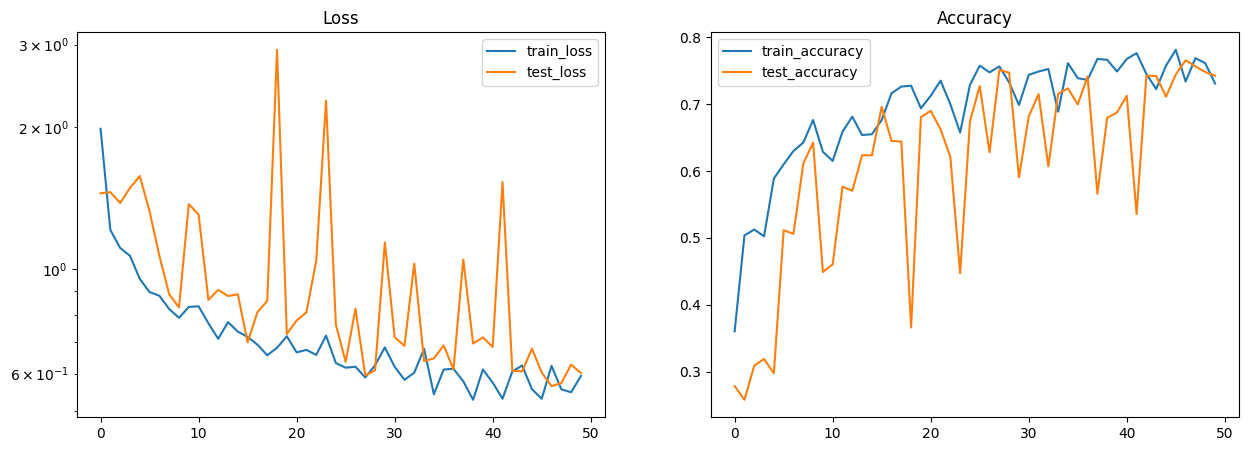

In [11]:
metrics_history = {
  'train_loss': [],
  'train_accuracy': [],
  'test_loss': [],
  'test_accuracy': [],
}

rngs = nnx.Rngs(0)
train_model = nnx.view(cnn_model, deterministic=False, use_running_average=False)
eval_model = nnx.view(cnn_model, deterministic=True, use_running_average=True)

for step, batch in enumerate(train_ds.as_numpy_iterator()):
  # Run the optimization for one step and make a stateful update to the following:
  # - The train state's model parameters
  # - The optimizer state
  # - The training loss and accuracy batch metrics
  train_step(train_model, optimizer, metrics, rngs, batch)

  if step > 0 and (step % eval_every == 0 or step == train_steps - 1):  # One training epoch has passed.
    # Log the training metrics.
    for metric, value in metrics.compute().items():  # Compute the metrics.
      metrics_history[f'train_{metric}'].append(value)  # Record the metrics.
    metrics.reset()  # Reset the metrics for the test set.

    # Compute the metrics on the test set after each training epoch.
    for test_batch in test_ds.as_numpy_iterator():
      eval_step(eval_model, metrics, test_batch)

    # Log the test metrics.
    for metric, value in metrics.compute().items():
      metrics_history[f'test_{metric}'].append(value)
    metrics.reset()  # Reset the metrics for the next training epoch.
    
    clear_output(wait=True)
    # Plot loss and accuracy in subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title('Loss')
    ax2.set_title('Accuracy')
    for dataset in ('train', 'test'):
      ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
      ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
    ax1.legend()
    ax1.set_yscale("log")
    ax2.legend()
    plt.show()

I ran this a few times messing with some variables, this took around 30 min to run

In [13]:
@nnx.jit
def pred_step(model: CNN, batch):
  logits = model(batch['image'], None)
  return logits.argmax(axis=1)

2026-04-15 23:03:31.746224: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


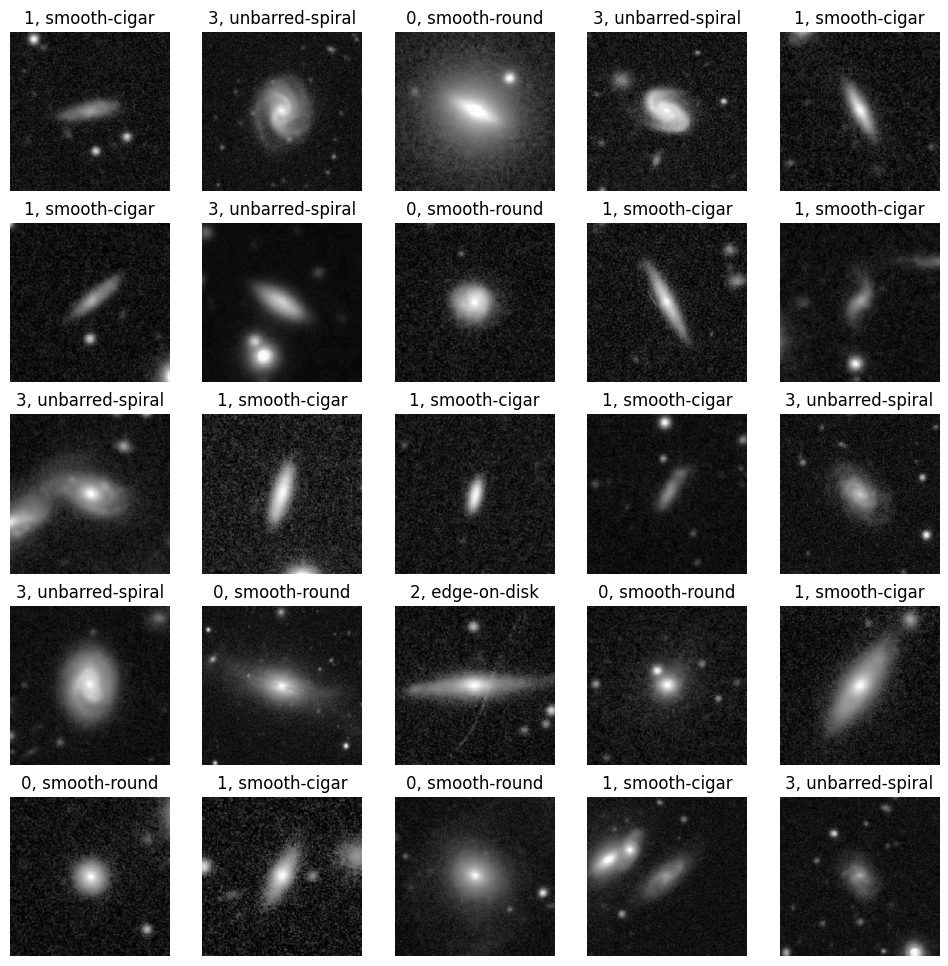

In [26]:
test_ds2: tf.data.Dataset = tfds.load('GalaxyMNIST', split='test')
test_ds2 = test_ds2.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    'label': sample['label'],
  }
)
test_ds2 = test_ds2.batch(32, drop_remainder=True).prefetch(1)

test_batch = test_ds2.as_numpy_iterator().next()
pred = pred_step(eval_model, test_batch)

fig, axs = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axs.flatten()):
    if pred[i] == 0:
        name = "smooth-round"
    elif pred[i] ==1:
        name = "smooth-cigar"
    elif pred[i] ==2:
        name = "edge-on-disk"
    else:
        name = "unbarred-spiral"
  
    ax.imshow(test_batch['image'][i, ..., 0], cmap='gray')
    #ax.set_title(f'label={pred[i]},{name}')
    ax.set_title(f'{pred[i]}, {name}')
    ax.axis('off')


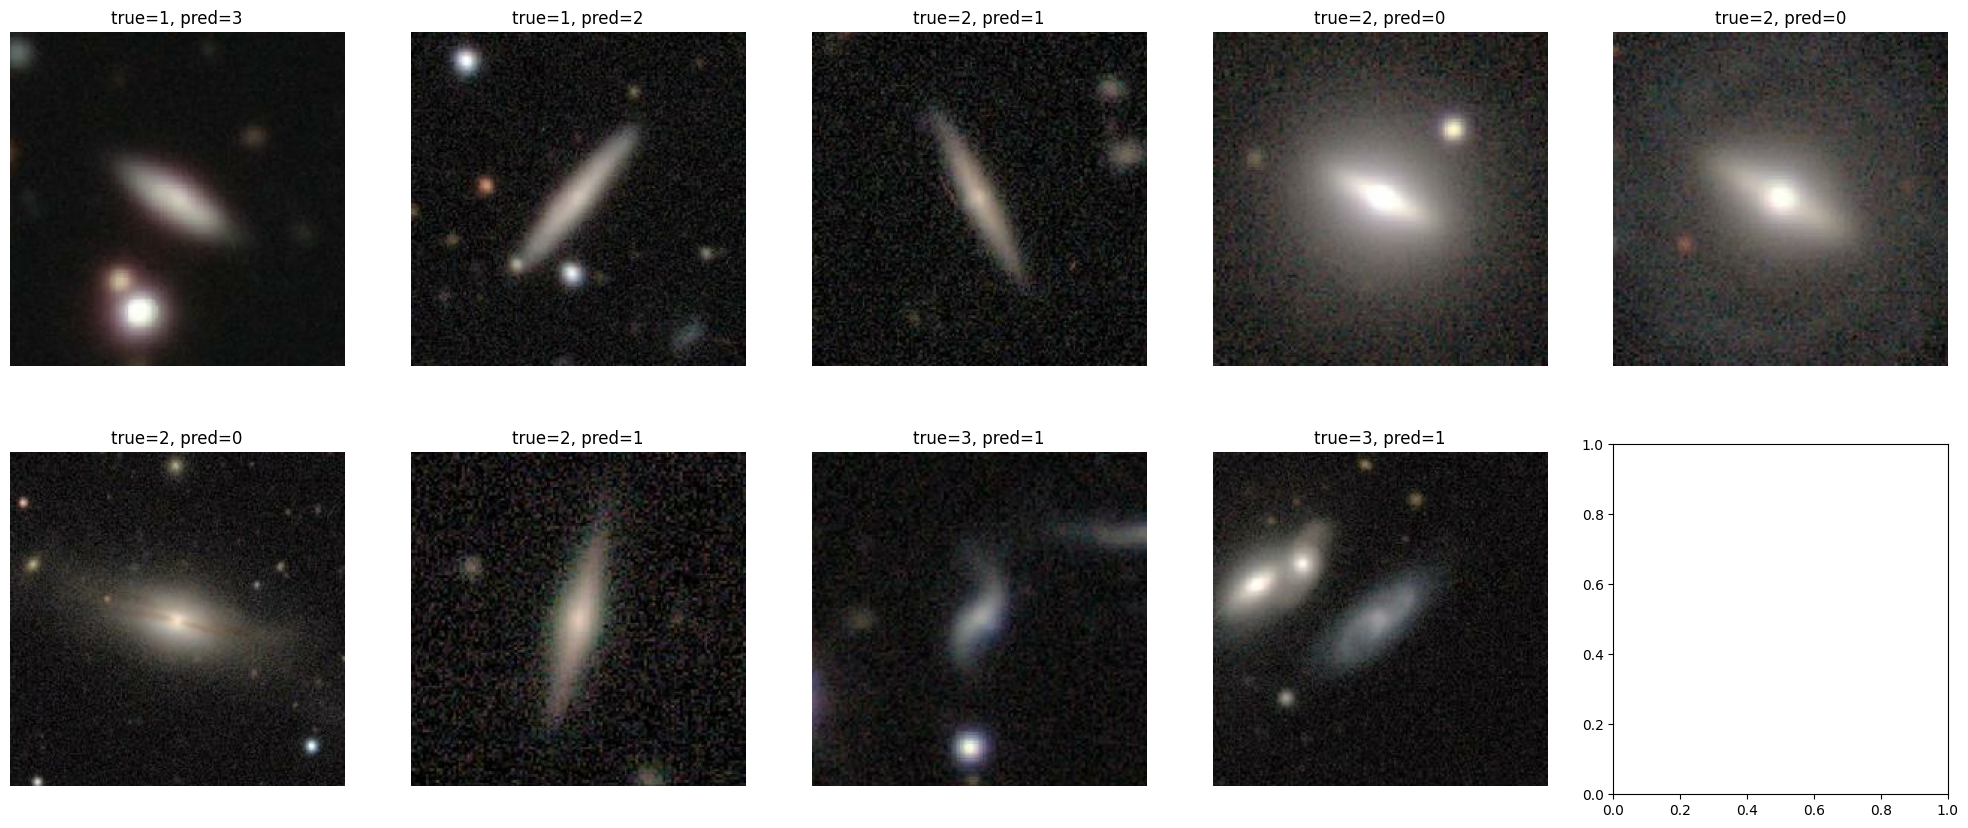

In [31]:

# Plot all mistakes
import math
bad_images = test_batch["image"][pred != test_batch["label"]]
bad_labels = test_batch["label"][pred != test_batch["label"]]
bad_preds = pred[pred != test_batch["label"]]
#print(bad_labels)

# Sort
sort_idx = np.argsort(bad_labels)
bad_images = bad_images[sort_idx]
bad_labels = bad_labels[sort_idx]
bad_preds = bad_preds[sort_idx]

confusion_matrix = hist.Hist(
    hist.axis.IntCategory(range(4), name="True"),
    hist.axis.IntCategory(range(4), name="Pred.")
)
confusion_matrix.fill(test_batch["label"], pred)


n = bad_labels.size
nrows = math.floor(n / 5.)+1
fig, axs = plt.subplots(nrows, 5, figsize=(25, 5*nrows))
if n == 0:
    print("No bad predictions")
elif n == 1:
    #print(bad_images)
    axs.imshow(bad_images[0], cmap="gray")
    axs.set_title(f"true={bad_labels[0]}, pred={bad_preds[0]}")
    axs.axis("off")
else:    
    for i in range(len(bad_images)):
        ax = axs.ravel()[i]
        ax.imshow(bad_images[i], cmap="gray")
        ax.set_title(f"true={bad_labels[i]}, pred={bad_preds[i]}")
        ax.axis("off")
    #for i, ax in enumerate(axs.ravel()):
    #    if i >= len(bad_images):
    #        continue

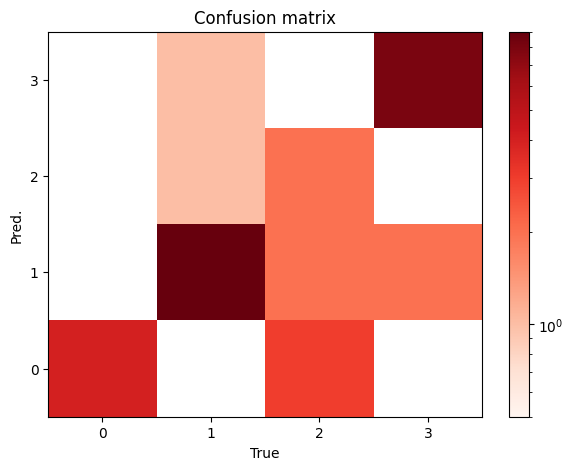

In [32]:
import matplotlib.ticker as plticker
from matplotlib.colors import LogNorm

loc = plticker.MultipleLocator(base=1.0) # this locator puts ticks at regular intervals

fig2, ax2 = plt.subplots(figsize=(7, 5))
w, x, y = confusion_matrix.to_numpy()
mesh = ax2.pcolormesh(x-0.5, y-0.5, w.T, cmap="Reds", norm=LogNorm(vmin=0.5, vmax=w.max()),)
ax2.set_xlabel("True")
ax2.set_ylabel("Pred.")
ax2.xaxis.set_major_locator(loc)
ax2.yaxis.set_major_locator(loc)
fig2.colorbar(mesh)
ax2.set_title("Confusion matrix")
plt.show()

In [33]:
# Compute accuracy
print(pred)
print(test_batch["label"])
acc = np.sum(pred == test_batch["label"]) / test_batch["label"].size
print(f"Accuracy = {acc}")

[1 3 0 3 1 1 3 0 1 1 3 1 1 1 3 3 0 2 0 1 0 1 0 1 3 3 2 2 1 0 3 1]
[1 3 2 3 1 1 1 0 2 3 3 1 1 1 3 3 2 2 0 1 0 1 0 3 3 3 2 1 1 2 3 2]
Accuracy = 0.71875


## Problem 3b: ROC curve
*10 points* 

Now consider your network as a binary classifier for the `unbarred-spiral` category (category 3). In other words, instead of selecting the single category with the highest score, we just care about whether a galaxy in `unbarred-spiral` or not. Specifically, let $p$ be the probability returned by the network for the `unbarred-spiral`category. For a given threshold $x\in[0, 1]$, we classify the image as `unbarred-spiral` if $p>x$.

We characterize the performance with two numbers:
1. Signal efficiency: the rate of classifying true unbarred-spiral images as `unbarred_spiral` (true positives), and
2. Fake rate: the rate of classifying non-`unbarred_spiral` images as `unbarred_spiral` (false positives).

The ROC curve is a visualization of the true positive vs. fake positive rate, scanning $x$ values over the whole range $[0, 1]$. See e.g. https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc for more information. 

Create a ROC plot, i.e., plot the signal efficiency (y-axis) vs. fake rate (x-axis) for $x\in[0, 1]$. Compute the "area under the curve" (AUC) metric by integrating the curve, and draw the AUC on the plot (remember, the AUC is 1 for a perfect classifier, and 0.5 for random guesses). Upload the ROC plot to your writeup, and discuss the results. 

(Comment: the AUC is a popular metric for machine learning competitions. In physics, we are typically more concerned with finding the point on the ROC curve that gives the best signal-vs-background discrimination, e.g., $s/\sqrt{b}$.)


In [34]:
# Make a ROC curve
@nnx.jit
def prob_step(model: CNN, batch):
  logits = model(batch['image'], None)
  prob = (jnp.exp(logits).T / jnp.sum(jnp.exp(logits), axis=1)).T
  return prob
    
prob = prob_step(eval_model, test_batch)
#print(prob.shape)
#print(prob[:10, :])

@nnx.jit
def binary_classify(model: CNN, batch, label: int, thresholds: np.typing.ArrayLike):  
    ''' 
    Return results of binary classification for class=label
    Shape: (batch_size, threshold_vals)
    '''
    logits = model(batch['image'], None)
    probs = prob_step(model, batch)[:, label]
    results = probs > thresholds[:, np.newaxis]
    return results

probs = {}
binary_results = {}
# Thresholds: logarithmic-ish near 1
thresholds = 1. - 10**np.linspace(-6, 0., 300)
#thresholds = np.linspace(0., 1., 100)
for cat in range(10):
    probs[cat] = prob_step(eval_model, test_batch)[:, cat]
    binary_results[cat] = binary_classify(eval_model, test_batch, cat, thresholds)

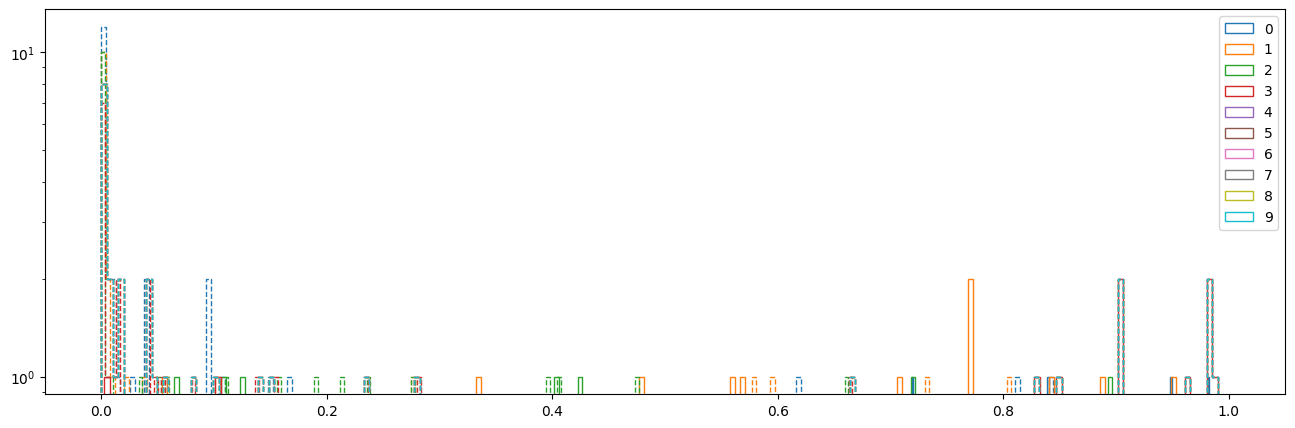

In [35]:
# Plot probability distributions
colors = sns.color_palette()
fig, ax = plt.subplots(figsize=(16, 5))

for cat in range(10):
    true_mask = test_batch["label"] == cat
    ax.hist(probs[cat][true_mask], 200, label=f"{cat}", color=colors[cat], histtype='step')
    ax.hist(probs[cat][~true_mask], 200, color=colors[cat], histtype='step', ls="--")
ax.set_yscale("log")
ax.legend()

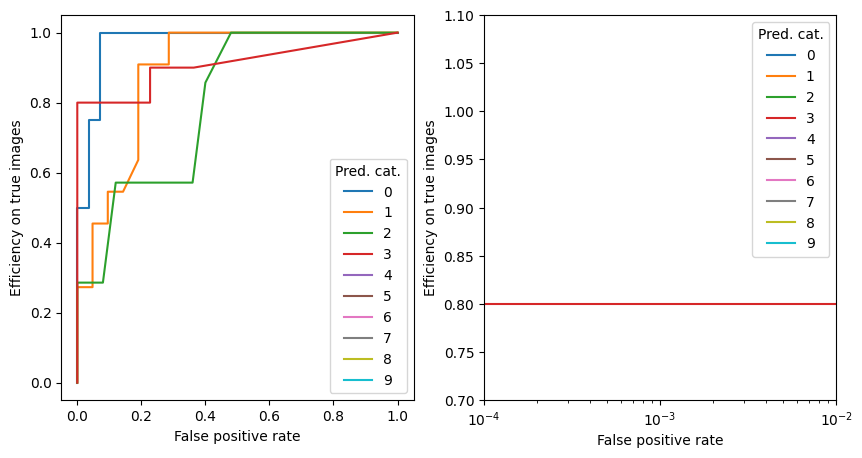

In [36]:
# Plot one-vs-all ROC curves
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
true_effs = {}
false_effs = {}
for pred_cat in range(10):
    #binary_results[cat]: (thresh, batch)
    true_mask = test_batch["label"] == pred_cat
    true_effs[pred_cat] = np.sum(binary_results[pred_cat][:, true_mask], axis=1) / np.sum(true_mask)
    false_effs[pred_cat] = np.sum(binary_results[pred_cat][:, ~true_mask], axis=1) / np.sum(~true_mask)
    axs.ravel()[0].plot(false_effs[pred_cat], true_effs[pred_cat], color=colors[pred_cat], label=f"{pred_cat}")
    axs.ravel()[1].plot(false_effs[pred_cat], true_effs[pred_cat], color=colors[pred_cat], label=f"{pred_cat}")
# Left plot: full ROC curve, linear axes
axs[0].set_xlabel("False positive rate")
axs[0].set_ylabel("Efficiency on true images")
axs[0].legend(title="Pred. cat.")

# Right plot: zoom interesting area, log x-axis
axs[1].set_xscale("log")
axs[1].set_xlim(1.e-4, 1.e-2)
axs[1].set_ylim(0.7, 1.1)
axs[1].set_xlabel("False positive rate")
axs[1].set_ylabel("Efficiency on true images")
axs[1].legend(title="Pred. cat.")

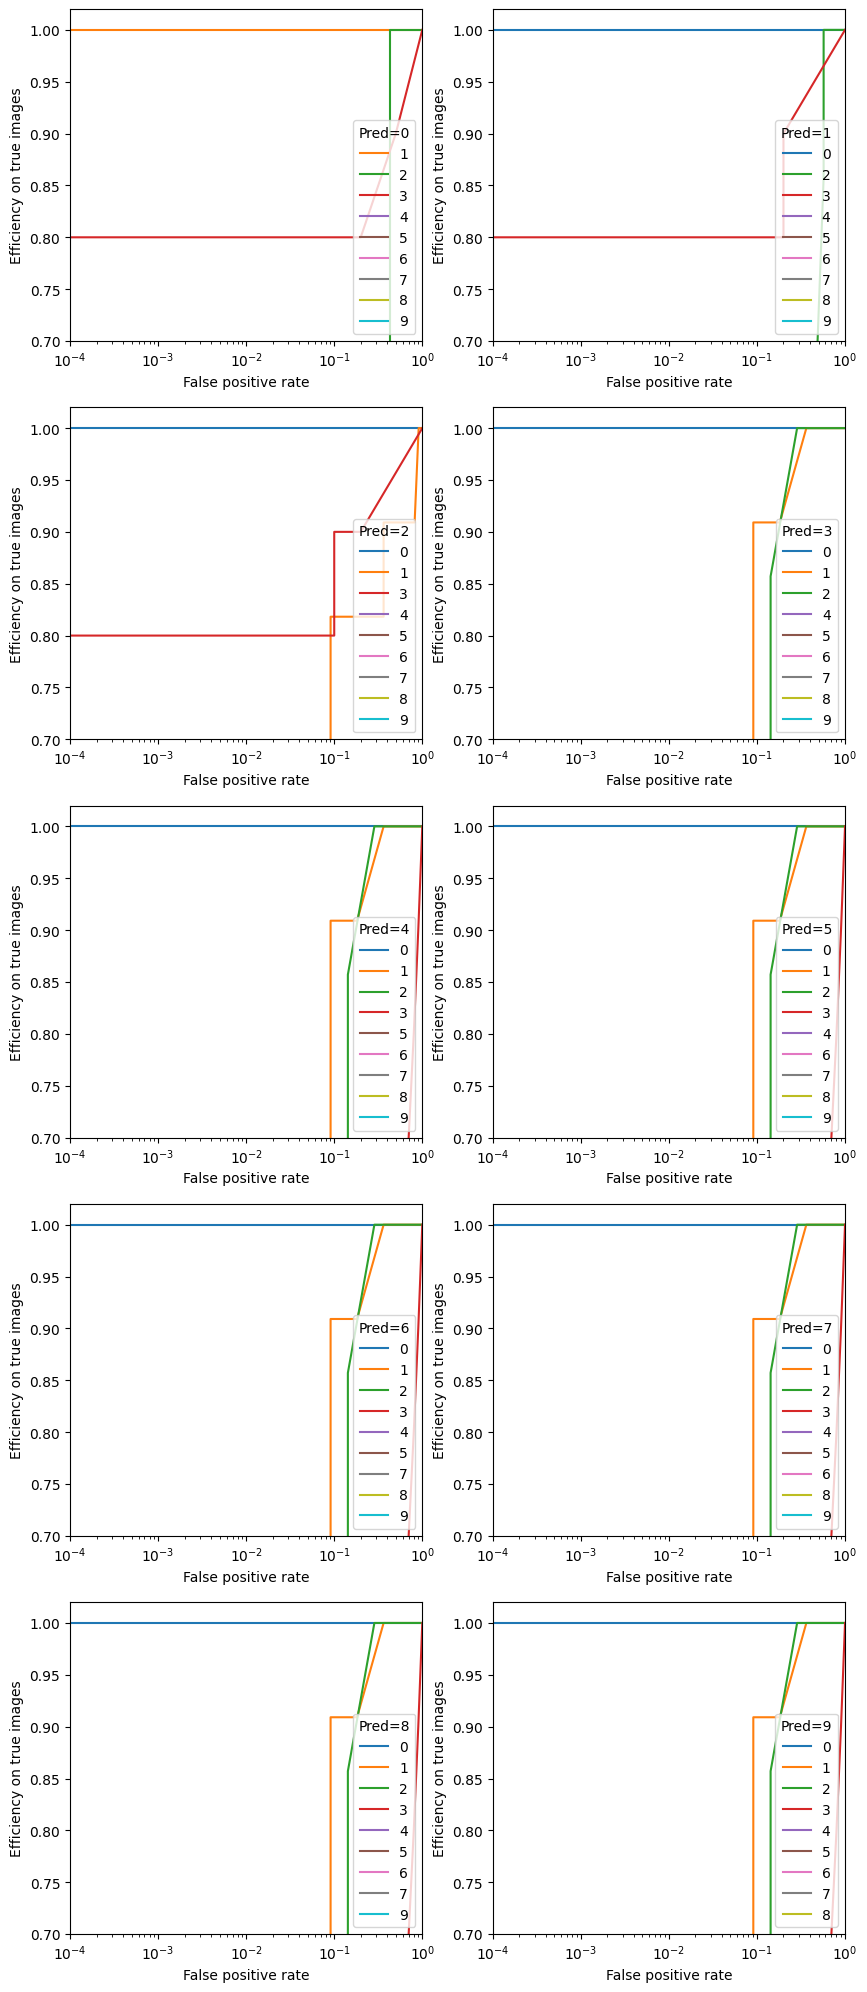

In [37]:
# Plot one-vs-one ROC curves
# Plot one-vs-all ROC curves
fig, axs = plt.subplots(5, 2, figsize=(10, 25))
true_effs = {}
false_effs = {}

# Truth classifications
true_masks = {}
for true_cat in range(10):
    true_masks[true_cat] = test_batch["label"] == cat

# Make ROC curves for each
eff_matrices = {} # key = (true_cat, pred_cat)
for pred_cat in range(10):
    for true_cat in range(10):
        true_mask = test_batch["label"] == true_cat
        eff_matrices[(true_cat, pred_cat)] = np.sum(binary_results[pred_cat][:, true_mask], axis=1) / np.sum(true_mask)

for pred_cat in range(10):    
    for true_cat in range(10):
        if pred_cat == true_cat: 
            continue
        axs.ravel()[pred_cat].plot(
            eff_matrices[(true_cat, pred_cat)], 
            eff_matrices[(true_cat, true_cat)], 
            color=colors[true_cat], label=f"{true_cat}")
    # Left plot: full ROC curve, linear axes
    axs.ravel()[pred_cat].set_xscale("log")
    axs.ravel()[pred_cat].set_xlim(1.e-4, 1.)
    axs.ravel()[pred_cat].set_ylim(0.7, 1.02)
    axs.ravel()[pred_cat].set_xlabel("False positive rate")
    axs.ravel()[pred_cat].set_ylabel("Efficiency on true images")
    axs.ravel()[pred_cat].legend(title=f"Pred={pred_cat}", loc="lower right")